# Phase 9 — Feature Engineering

## What feature engineering is

Raw data columns are not always in the right form
for a machine learning model to use effectively.

Feature engineering transforms raw columns into
mathematical representations that capture the
business patterns we discovered in phases 4-8.

## Why this phase exists

The model does not know that:
- Month-to-month contracts are dangerous
- New customers churn 5x more than loyal ones
- Electronic check signals low commitment
- Engagement score predicts retention

We must encode these business insights as
numerical features so the model can learn them.

## What this phase produces

A clean, fully numeric feature matrix where:
- Every column is a number (no text)
- Every column represents a business-meaningful signal
- The matrix is ready for scikit-learn input

This feature matrix is saved to:
data/cleaned/features_matrix.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

print("Data loaded for feature engineering")
print(f"Shape : {df.shape}")
print()

# ── AUDIT EXISTING COLUMNS ───────────────────────────────
# Before engineering anything we need to know
# which columns are already numeric and usable
# which are text and need encoding
# which are identifiers that should be dropped

print("Column audit:")
print()
print(f"{'Column':<25} {'Type':<12} {'Action'}")
print("-" * 55)

# Define what to do with each column
column_plan = {
    'customerID'      : ('object' , 'DROP — identifier only'),
    'gender'          : ('object' , 'ENCODE — binary'),
    'SeniorCitizen'   : ('int64'  , 'KEEP — already numeric'),
    'Partner'         : ('object' , 'ENCODE — binary'),
    'Dependents'      : ('object' , 'ENCODE — binary'),
    'tenure'          : ('int64'  , 'KEEP — already numeric'),
    'PhoneService'    : ('object' , 'ENCODE — binary'),
    'MultipleLines'   : ('object' , 'ENCODE — multi-value'),
    'InternetService' : ('object' , 'ENCODE — multi-value'),
    'OnlineSecurity'  : ('object' , 'ENCODE — binary'),
    'OnlineBackup'    : ('object' , 'ENCODE — binary'),
    'DeviceProtection': ('object' , 'ENCODE — binary'),
    'TechSupport'     : ('object' , 'ENCODE — binary'),
    'StreamingTV'     : ('object' , 'ENCODE — binary'),
    'StreamingMovies' : ('object' , 'ENCODE — binary'),
    'Contract'        : ('object' , 'ENCODE — ordinal'),
    'PaperlessBilling': ('object' , 'ENCODE — binary'),
    'PaymentMethod'   : ('object' , 'ENCODE — multi-value'),
    'MonthlyCharges'  : ('float64', 'KEEP — already numeric'),
    'TotalCharges'    : ('float64', 'KEEP — already numeric'),
    'Churn'           : ('int64'  , 'TARGET — do not use as feature')
}

for col, (dtype, action) in column_plan.items():
    actual_type = str(df[col].dtype)
    print(f"{col:<25} {actual_type:<12} {action}")

Data loaded for feature engineering
Shape : (7032, 21)

Column audit:

Column                    Type         Action
-------------------------------------------------------
customerID                str          DROP — identifier only
gender                    str          ENCODE — binary
SeniorCitizen             int64        KEEP — already numeric
Partner                   str          ENCODE — binary
Dependents                str          ENCODE — binary
tenure                    int64        KEEP — already numeric
PhoneService              str          ENCODE — binary
MultipleLines             str          ENCODE — multi-value
InternetService           str          ENCODE — multi-value
OnlineSecurity            str          ENCODE — binary
OnlineBackup              str          ENCODE — binary
DeviceProtection          str          ENCODE — binary
TechSupport               str          ENCODE — binary
StreamingTV               str          ENCODE — binary
StreamingMovies           

In [2]:
# ── STEP 1: DROP IDENTIFIER ──────────────────────────────
# customerID is just a label — contains no information
# that helps predict churn. Models learn patterns not IDs.
# Including it would cause the model to memorise
# specific customer IDs rather than learn real patterns
# This is called data leakage — and it is dangerous

# We keep customerID separately so we can attach
# predictions back to real customers in Phase 11

customer_ids = df['customerID'].copy()
df_feat = df.drop(columns=['customerID'])

print(f"customerID saved separately : {len(customer_ids)} IDs")
print(f"Dropped from feature matrix")
print()

# ── STEP 2: ENCODE BINARY YES/NO COLUMNS ─────────────────
# These columns contain only Yes or No
# We convert Yes=1, No=0
# This is called binary encoding or label encoding

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

# For gender: Female=0, Male=1
df_feat['gender'] = df_feat['gender'].map(
    {'Female': 0, 'Male': 1}
)

# For all others: No=0, Yes=1
yes_no_cols = [
    'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling'
]

for col in yes_no_cols:
    df_feat[col] = df_feat[col].map({'No': 0, 'Yes': 1})

print("Binary columns encoded:")
for col in ['gender'] + yes_no_cols:
    print(f"  {col} : {df_feat[col].unique()}")

customerID saved separately : 7032 IDs
Dropped from feature matrix

Binary columns encoded:
  gender : [0 1]
  Partner : [1 0]
  Dependents : [0 1]
  PhoneService : [0 1]
  PaperlessBilling : [1 0]


In [3]:
# ── STEP 3: ENCODE SERVICE COLUMNS ───────────────────────
# These columns have three possible values:
# 'Yes', 'No', 'No internet service' or 'No phone service'
# We treat all non-Yes values as 0
# because from a business perspective
# 'No internet service' = not using the feature = 0

service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

for col in service_cols:
    # Map Yes to 1, everything else to 0
    df_feat[col] = df_feat[col].apply(
        lambda x: 1 if x == 'Yes' else 0
    )

print("Service columns encoded (Yes=1, other=0):")
for col in service_cols:
    vc = df_feat[col].value_counts().to_dict()
    print(f"  {col:<20} : {vc}")

# ── STEP 4: BUILD ENGAGEMENT SCORE FEATURE ───────────────
# Sum all service binary columns
# This is the product stickiness score
# we validated in Phase 8

df_feat['engagement_score'] = df_feat[service_cols].sum(
    axis=1
)

print()
print(f"Engagement score created")
print(f"Range : {df_feat['engagement_score'].min()} to "
      f"{df_feat['engagement_score'].max()}")

# ── STEP 5: ENCODE INTERNET SERVICE ──────────────────────
# InternetService has three categories:
# DSL, Fiber optic, No
# We use one-hot encoding — creates a separate binary
# column for each category
# This avoids implying DSL < Fiber < No numerically

internet_dummies = pd.get_dummies(
    df_feat['InternetService'],
    prefix='Internet'
)

# pd.get_dummies() creates new columns automatically
# prefix='Internet' names them Internet_DSL,
# Internet_Fiber optic, Internet_No

# We drop the original column and add the new ones
df_feat = pd.concat(
    [df_feat.drop(columns=['InternetService']),
     internet_dummies],
    axis=1
)

print()
print("InternetService one-hot encoded:")
print([c for c in df_feat.columns if 'Internet' in c])

Service columns encoded (Yes=1, other=0):
  OnlineSecurity       : {0: 5017, 1: 2015}
  OnlineBackup         : {0: 4607, 1: 2425}
  DeviceProtection     : {0: 4614, 1: 2418}
  TechSupport          : {0: 4992, 1: 2040}
  StreamingTV          : {0: 4329, 1: 2703}
  StreamingMovies      : {0: 4301, 1: 2731}
  MultipleLines        : {0: 4065, 1: 2967}

Engagement score created
Range : 0 to 7

InternetService one-hot encoded:
['Internet_DSL', 'Internet_Fiber optic', 'Internet_No']


In [4]:
# ── STEP 6: ENCODE CONTRACT TYPE — ORDINAL ───────────────
# Contract type has a natural order of commitment:
# Month-to-month = 0 (lowest commitment)
# One year = 1       (medium commitment)
# Two year = 2       (highest commitment)
#
# We use ordinal encoding here — not one-hot —
# because the order MATTERS and we want the model
# to understand that two-year is more committed
# than one-year which is more than month-to-month

df_feat['Contract'] = df_feat['Contract'].map({
    'Month-to-month': 0,
    'One year'      : 1,
    'Two year'      : 2
})

print("Contract encoded as ordinal:")
print(df_feat['Contract'].value_counts().sort_index())
print()

# ── STEP 7: ENCODE PAYMENT METHOD ────────────────────────
# PaymentMethod has 4 categories with no natural order
# So we use one-hot encoding
# But we also create a meaningful derived feature:
# is_auto_payment — captures the commitment signal
# we found in Phase 4 SQL analysis

# First create the derived binary feature
# Electronic check and Mailed check = manual = 0
# Bank transfer auto and Credit card auto = automatic = 1

df_feat['is_auto_payment'] = df_feat[
    'PaymentMethod'
].apply(
    lambda x: 1 if 'automatic' in x.lower() else 0
)

print("Auto payment feature created:")
print(df_feat['is_auto_payment'].value_counts())
print()

# Now one-hot encode the full payment method
payment_dummies = pd.get_dummies(
    df_feat['PaymentMethod'],
    prefix='Payment'
)

df_feat = pd.concat(
    [df_feat.drop(columns=['PaymentMethod']),
     payment_dummies],
    axis=1
)

print("PaymentMethod one-hot encoded:")
print([c for c in df_feat.columns if 'Payment' in c])

Contract encoded as ordinal:
Contract
0    3875
1    1472
2    1685
Name: count, dtype: int64

Auto payment feature created:
is_auto_payment
0    3969
1    3063
Name: count, dtype: int64

PaymentMethod one-hot encoded:
['Payment_Bank transfer (automatic)', 'Payment_Credit card (automatic)', 'Payment_Electronic check', 'Payment_Mailed check']


In [5]:
# ── STEP 8: ENGINEER BUSINESS-DERIVED FEATURES ───────────
# These are features we CREATE from existing columns
# based on our business understanding
# They encode the insights from our analysis directly
# into the model input

# ── FEATURE 1: TENURE GROUP ──────────────────────────────
# Encode the tenure groups from our cohort analysis
# as an ordinal variable
# New=0, Growing=1, Mature=2

def tenure_group_encode(tenure):
    if tenure <= 12:
        return 0    # New — highest risk
    elif tenure <= 36:
        return 1    # Growing — moderate risk
    else:
        return 2    # Mature — lowest risk

df_feat['tenure_group'] = df_feat['tenure'].apply(
    tenure_group_encode
)

# ── FEATURE 2: CHARGES RATIO ─────────────────────────────
# TotalCharges / tenure = average charge per month
# This normalises total charges by tenure length
# A customer with TotalCharges=$500 who has been
# here 5 months is very different from one who
# has been here 50 months
# charges_per_month reveals pricing tier stability

df_feat['charges_per_month'] = np.where(
    df_feat['tenure'] > 0,
    df_feat['TotalCharges'] / df_feat['tenure'],
    df_feat['MonthlyCharges']
)

# np.where(condition, value_if_true, value_if_false)
# We use MonthlyCharges as fallback for tenure=0
# to avoid division by zero

df_feat['charges_per_month'] = df_feat[
    'charges_per_month'
].round(2)

# ── FEATURE 3: HIGH VALUE FLAG ────────────────────────────
# Binary flag for premium customers (top 33% of charges)
# Based on p66 threshold from Phase 8

p66 = df_feat['MonthlyCharges'].quantile(0.66)
df_feat['is_high_value'] = (
    df_feat['MonthlyCharges'] > p66
).astype(int)

# ── FEATURE 4: HIGH RISK COMBINATION FLAG ────────────────
# Encodes the high-risk customer profile we identified:
# New customer + Month-to-month + Manual payment
# If all three risk factors present = 1, else = 0

df_feat['is_high_risk_profile'] = (
    (df_feat['tenure_group'] == 0) &
    (df_feat['Contract'] == 0) &
    (df_feat['is_auto_payment'] == 0)
).astype(int)

# .astype(int) converts True/False to 1/0

print("Engineered features created:")
print()
print(f"tenure_group distribution:")
print(df_feat['tenure_group'].value_counts().sort_index())
print()
print(f"is_high_value distribution:")
print(df_feat['is_high_value'].value_counts())
print()
print(f"is_high_risk_profile distribution:")
print(df_feat['is_high_risk_profile'].value_counts())
print()
print(f"charges_per_month sample:")
print(df_feat['charges_per_month'].describe().round(2))

Engineered features created:

tenure_group distribution:
tenure_group
0    2175
1    1856
2    3001
Name: count, dtype: int64

is_high_value distribution:
is_high_value
0    4644
1    2388
Name: count, dtype: int64

is_high_risk_profile distribution:
is_high_risk_profile
0    5437
1    1595
Name: count, dtype: int64

charges_per_month sample:
count    7032.00
mean       64.80
std        30.19
min        13.78
25%        36.18
50%        70.38
75%        90.18
max       121.40
Name: charges_per_month, dtype: float64


In [6]:
# ── STEP 9: FINALISE FEATURE MATRIX ─────────────────────
# Separate features (X) from target (y)
# X = everything the model uses to predict
# y = what the model is trying to predict (Churn)

# Separate target variable
y = df_feat['Churn'].copy()
X = df_feat.drop(columns=['Churn'])

print("Feature matrix finalised")
print(f"X shape : {X.shape}  (features)")
print(f"y shape : {y.shape}  (target)")
print()
print(f"Total features : {X.shape[1]}")
print()
print("All feature names:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# ── STEP 10: CORRELATION WITH CHURN ──────────────────────
# Which features correlate most strongly with churn?
# This gives us a preview of which features the
# model will find most useful

# We can only calculate correlation on numeric columns
# All columns should now be numeric
correlations = X.corrwith(y).abs().sort_values(
    ascending=False
)

print()
print("=" * 50)
print("TOP FEATURES BY CORRELATION WITH CHURN")
print("=" * 50)
print()
print(f"{'Feature':<30} {'Correlation'}")
print("-" * 45)
for feat, corr in correlations.head(15).items():
    bar = '█' * int(corr * 30)
    print(f"{feat:<30} {corr:.4f}  {bar}")

# ── STEP 11: SAVE THE FEATURE MATRIX ─────────────────────
# Save X and y together as one file
# We add customer_ids back so we can identify
# which customer each row represents later

final_matrix = X.copy()
final_matrix['Churn'] = y
final_matrix['customerID'] = customer_ids.values

final_matrix.to_csv(
    '../data/cleaned/features_matrix.csv',
    index=False
)

print()
print(f"Feature matrix saved to data/cleaned/")
print(f"Shape : {final_matrix.shape}")
print(f"File  : features_matrix.csv")

Feature matrix finalised
X shape : (7032, 30)  (features)
y shape : (7032,)  (target)

Total features : 30

All feature names:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. OnlineSecurity
   9. OnlineBackup
  10. DeviceProtection
  11. TechSupport
  12. StreamingTV
  13. StreamingMovies
  14. Contract
  15. PaperlessBilling
  16. MonthlyCharges
  17. TotalCharges
  18. engagement_score
  19. Internet_DSL
  20. Internet_Fiber optic
  21. Internet_No
  22. is_auto_payment
  23. Payment_Bank transfer (automatic)
  24. Payment_Credit card (automatic)
  25. Payment_Electronic check
  26. Payment_Mailed check
  27. tenure_group
  28. charges_per_month
  29. is_high_value
  30. is_high_risk_profile

TOP FEATURES BY CORRELATION WITH CHURN

Feature                        Correlation
---------------------------------------------
Contract                       0.3961  ███████████
tenure                         0.3540  ███

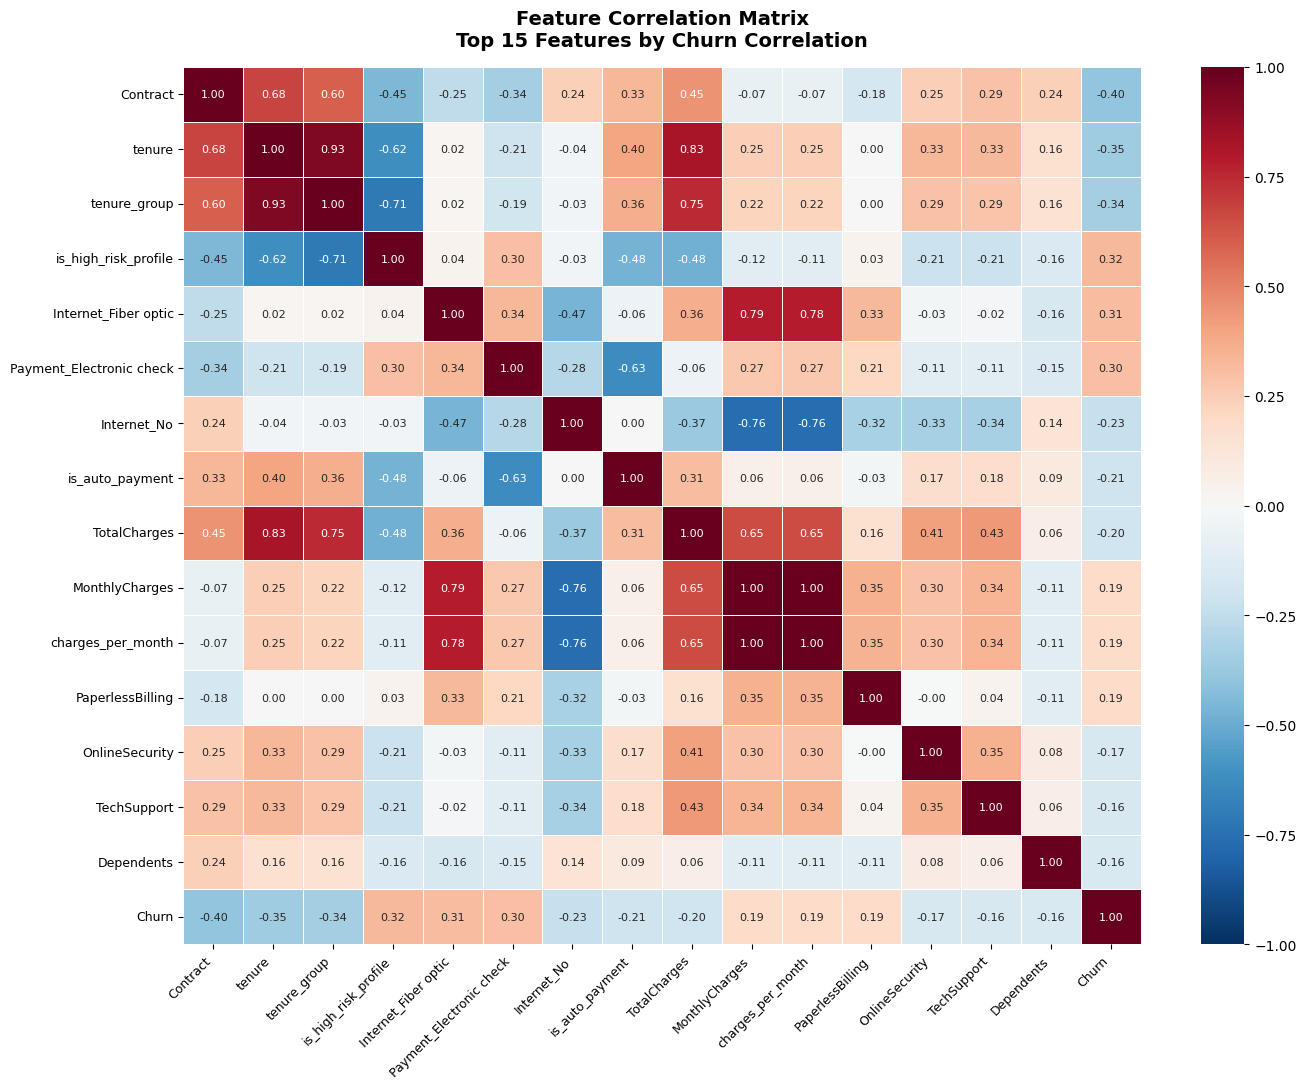

Feature correlation heatmap saved


In [7]:
# ── CORRELATION HEATMAP ───────────────────────────────────
# Visualise how all features relate to each other
# and to the Churn target
# Dark red = strong positive correlation
# Dark blue = strong negative correlation
# Near white = little relationship

# Select top 15 features by churn correlation
# for a readable heatmap size
top_features = correlations.head(15).index.tolist()
top_features_with_churn = top_features + ['Churn']

# Calculate correlation matrix
corr_matrix = df_feat[top_features_with_churn].corr()

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title(
    'Feature Correlation Matrix\n'
    'Top 15 Features by Churn Correlation',
    fontweight='bold',
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(
    '../reports/figures/10_feature_correlation.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Feature correlation heatmap saved")

In [1]:
import pandas as pd

# Load the saved feature matrix
fm = pd.read_csv('../data/cleaned/features_matrix.csv')

y = fm['Churn']
X = fm.drop(columns=['Churn', 'customerID'])

# Calculate correlations
correlations = X.corrwith(y).abs().sort_values(
    ascending=False
)

print("=" * 52)
print("TOP 15 FEATURES BY CORRELATION WITH CHURN")
print("=" * 52)
print()
print(f"{'Rank':<6} {'Feature':<30} {'Correlation'}")
print("-" * 50)

for rank, (feat, corr) in enumerate(
    correlations.head(15).items(), 1
):
    bar = '█' * int(corr * 25)
    print(f"{rank:<6} {feat:<30} {corr:.4f}  {bar}")

print()
print(f"Total features : {len(correlations)}")
print(f"Matrix shape   : {fm.shape}")

TOP 15 FEATURES BY CORRELATION WITH CHURN

Rank   Feature                        Correlation
--------------------------------------------------
1      Contract                       0.3961  █████████
2      tenure                         0.3540  ████████
3      tenure_group                   0.3404  ████████
4      is_high_risk_profile           0.3229  ████████
5      Internet_Fiber optic           0.3075  ███████
6      Payment_Electronic check       0.3015  ███████
7      Internet_No                    0.2276  █████
8      is_auto_payment                0.2104  █████
9      TotalCharges                   0.1995  ████
10     MonthlyCharges                 0.1929  ████
11     charges_per_month              0.1920  ████
12     PaperlessBilling               0.1915  ████
13     OnlineSecurity                 0.1713  ████
14     TechSupport                    0.1647  ████
15     Dependents                     0.1631  ████

Total features : 30
Matrix shape   : (7032, 32)


## Feature Engineering — Final Results

### Feature matrix produced
- 30 features total
- 7,032 customer rows
- Saved to data/cleaned/features_matrix.csv

### Top 5 features by correlation with churn

1. Contract (0.3961)
   Strongest predictor — confirmed across all phases
   Month-to-month = highest churn risk

2. tenure (0.3540)
   How long a customer has been with the company
   Longer tenure = lower churn probability

3. tenure_group (0.3404)
   Engineered feature — our cohort groupings
   Captures non-linear lifecycle risk pattern

4. is_high_risk_profile (0.3229)
   Engineered feature — combined risk flag
   New + month-to-month + manual payment
   Business logic encoded as a feature

5. Internet_Fiber optic (0.3075)
   Unexpected finding — premium internet customers
   churn more, consistent with premium price
   sensitivity finding in EDA

### Key validation
Our engineered features (is_high_risk_profile,
tenure_group) rank higher than many raw columns.
This confirms that business domain knowledge
encoded as features adds real predictive value
beyond what raw data alone provides.

### Phase 9 complete
Feature matrix is ready for machine learning.
Phase 10 builds the churn prediction model
using these 30 features as input.